Base learners:

- rf_custom_F1
- rf_custom_Recall
- AvalancheNet (neural network)

Meta-learner:
A simple logistic regression or another classifier (e.g. random forest or MLP) trained on the predictions of the base models.



In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

#Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import plot_confusion_matrix,
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
from matplotlib.pylab import rcParams
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [23]:
# Load and clean data
full = pd.read_csv("C:/Users/annaw/Desktop/DataScience/Datasets/full_dataset.csv", dtype={91: str})
print(f"X_train shape: {full.shape}")

# drop columns with >20% missing
full_clean = full.dropna(thresh=len(full)*0.8, axis=1)  
print(full_clean['avalancheDay1'].value_counts())

full_clean = full_clean.dropna()
full_clean = full_clean.select_dtypes(include=[np.number])
full_clean = full_clean.drop(columns=[col for col in ['year', 'datum'] if col in full_clean.columns])
print(full_clean['avalancheDay1'].value_counts())

# Split features and target
X = full_clean.drop(columns=["avalancheDay1"])
y = full_clean["avalancheDay1"]

# Single consistent split (for both RF and NN)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

# RF will train on X_train_full and test on X_test
# NN will train on X_train_full (but create its own val set)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_nn = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save these for SHAP use
X_background = X_train_scaled[:100]
X_explain = X_test_scaled

# Convert to PyTorch tensors

#Convert inputs
X_train_nn = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_nn = torch.tensor(X_val_nn, dtype=torch.float32)
X_test_nn = torch.tensor(X_test_scaled, dtype=torch.float32)

#Convert lables
y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

X_train shape: (11362, 95)
avalancheDay1
0    10638
1      724
Name: count, dtype: int64
avalancheDay1
0    9598
1     695
Name: count, dtype: int64


In [45]:
#Wrap the pytorch model for stacking

from sklearn.base import BaseEstimator, ClassifierMixin

class TorchNNWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def fit(self, X, y):
        # Skip training here; assume pretrained model
        self.classes_ = np.array([0, 1])  # binary classification
        return self

    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32)
            logits = self.model(X_tensor)
            probs = torch.sigmoid(logits).numpy().flatten()
        return np.vstack([1 - probs, probs]).T

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs > self.threshold).astype(int)


In [29]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define the architecture again
class AvalancheNet(nn.Module):
    def __init__(self, input_dim):
        super(AvalancheNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(32, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x
model = AvalancheNet(input_dim=X_train_nn.shape[1])  # use same input dim as during training

# Load saved weights
model.load_state_dict(torch.load("avalanche_net.pth"))
model.eval()  # Set to evaluation mode

# Wrap PyTorch model
nn_wrapper = TorchNNWrapper(model=model, threshold=float(0.65))

In [30]:
#F1 optimized RF
rf_custom_F1 = RandomForestClassifier(
    class_weight=None,
    max_depth=20,
    max_features=None,
    min_samples_leaf=5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
# Train the model
rf_custom_F1.fit(X_train_scaled, y_train)
# Predict on test set
y_pred_F1 = rf_custom_F1.predict(X_test_scaled)

#Recall optimized RF

rf_custom_Recall = RandomForestClassifier(
    class_weight='balanced',
    max_depth=10,
    max_features="sqrt",
    min_samples_leaf=200,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
# Train the model
rf_custom_Recall.fit(X_train_scaled, y_train)
# Predict on test set
y_pred_Recall = rf_custom_Recall.predict(X_test_scaled)


# STACKING

In [41]:
# Build stacking ensemble
stacked_model = StackingClassifier(
    estimators=[
        ('rf_f1', rf_custom_F1),
        ('rf_recall', rf_custom_Recall),
        ('nn', nn_wrapper)
    ],
    final_estimator=LogisticRegression(),  # Can also use RF or Gradient Boosting here
    cv=5,  # Cross-validation for meta-learner
    passthrough=False  # If True, pass original features along with base learner outputs
)

# Fit ensemble model
stacked_model.fit(X_test_scaled, y_test)  # or X_train_scaled/y_train if available

# Predict
y_pred_stack = stacked_model.predict(X_test_scaled)
print("\n=== Stacked Model Performance ===")
print(classification_report(y_test, y_pred_stack))
print(confusion_matrix(y_test, y_pred_stack))



=== Stacked Model Performance ===
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      1923
         1.0       0.93      0.90      0.92       136

    accuracy                           0.99      2059
   macro avg       0.96      0.95      0.96      2059
weighted avg       0.99      0.99      0.99      2059

[[1914    9]
 [  13  123]]


In [42]:
# Build stacking ensemble
stacked_model = StackingClassifier(
    estimators=[
        ('rf_f1', rf_custom_F1),
        ('rf_recall', rf_custom_Recall),
        ('nn', nn_wrapper)
    ],
    final_estimator=LogisticRegression(),  # Can also use RF or Gradient Boosting here
    cv=5,  # Cross-validation for meta-learner
    passthrough=True  # If True, pass original features along with base learner outputs
)

# Fit ensemble model
stacked_model.fit(X_test_scaled, y_test)  # or X_train_scaled/y_train if available

# Predict
y_pred_stack = stacked_model.predict(X_test_scaled)
print("\n=== Stacked Model Performance ===")
print(classification_report(y_test, y_pred_stack))
print(confusion_matrix(y_test, y_pred_stack))



=== Stacked Model Performance ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1923
         1.0       0.98      0.95      0.96       136

    accuracy                           1.00      2059
   macro avg       0.99      0.97      0.98      2059
weighted avg       1.00      1.00      1.00      2059

[[1920    3]
 [   7  129]]


In [38]:
from sklearn.ensemble import GradientBoostingClassifier

stacked_model = StackingClassifier(
    estimators=[
        ('rf_f1', rf_custom_F1),
        ('rf_recall', rf_custom_Recall),
        ('nn', nn_wrapper)
    ],
    final_estimator=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3),
    cv=5,
    passthrough=False
)

# Fit ensemble model
stacked_model.fit(X_test_scaled, y_test)  # or X_train_scaled/y_train if available

# Predict
y_pred_stack = stacked_model.predict(X_test_scaled)
print("\n=== Stacked Model Performance ===")
print(classification_report(y_test, y_pred_stack))
print(confusion_matrix(y_test, y_pred_stack))


=== Stacked Model Performance ===
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97      1923
         1.0       0.90      0.28      0.43       136

    accuracy                           0.95      2059
   macro avg       0.93      0.64      0.70      2059
weighted avg       0.95      0.95      0.94      2059

[[1919    4]
 [  98   38]]


In [43]:
from sklearn.ensemble import GradientBoostingClassifier

stacked_model = StackingClassifier(
    estimators=[
        ('rf_f1', rf_custom_F1),
        ('rf_recall', rf_custom_Recall),
        ('nn', nn_wrapper)
    ],
    final_estimator=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3),
    cv=5,
    passthrough=True
)

# Fit ensemble model
stacked_model.fit(X_test_scaled, y_test)  # or X_train_scaled/y_train if available

# Predict
y_pred_stack = stacked_model.predict(X_test_scaled)
print("\n=== Stacked Model Performance ===")
print(classification_report(y_test, y_pred_stack))
print(confusion_matrix(y_test, y_pred_stack))

#It gets super duper good if i use passthrough = True 
#This gives the meta-learner access to the original features and the predictions

#But carefull because the risk of overfitting increases
#Need to check!!!

# Predict on training set
y_train_pred = stacked_model.predict(X_train_scaled)
print("\n=== Training Performance ===")
print(classification_report(y_train, y_train_pred))

# Predict on test set
y_test_pred = stacked_model.predict(X_test_scaled)
print("\n=== Test Performance ===")
print(classification_report(y_test, y_test_pred))



=== Stacked Model Performance ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1923
         1.0       1.00      0.99      0.99       136

    accuracy                           1.00      2059
   macro avg       1.00      0.99      1.00      2059
weighted avg       1.00      1.00      1.00      2059

[[1923    0]
 [   2  134]]

=== Training Performance ===
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      6153
         1.0       0.93      0.92      0.93       434

    accuracy                           0.99      6587
   macro avg       0.96      0.96      0.96      6587
weighted avg       0.99      0.99      0.99      6587


=== Test Performance ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1923
         1.0       1.00      0.99      0.99       136

    accuracy                           1.00      2059
   macro a

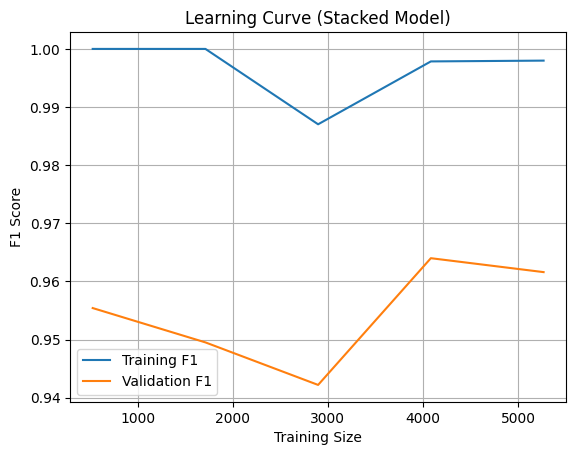

In [44]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    stacked_model, X_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training F1')
plt.plot(train_sizes, test_mean, label='Validation F1')
plt.xlabel('Training Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve (Stacked Model)')
plt.legend()
plt.grid(True)
plt.show()

#Training F1 is very high and stable -> model is very capable of fitting the training data
#Validation F1 stays consistently high (~0.94–0.96) -> this is an indicator of strong generalization (not just memorization)
# There’s no dramatic overfitting gap = model doesn't do much worse on validation than training

# Future work

Tune the base modeks with stacking in mind to maybe get slightly better results

- Train a slightly underfit RF and a slightly overfit NN to capture different biases
- Use different feature subsets for each model (a technique called stacked generalization with feature diversity)

# LIMITATION
We did a random split - the model might be able to somehow use temporal trends and therefore is really good in predicting 


Random split might be OKEY IF: Goal is to simulate short-term nowcasting, where the model is updated frequently and predicts tomorrow based on today’s data
→ Then a random split may approximate real-world model updating.

KEEP IN MIND
If your goal is to test generalization across seasons (e.g., will this model trained on 2018–2020 work in 2023?),
→ You must split by year or season to avoid data leakage across time.
!!! You don't randomly split in time-series datasets because it doesn't respect the temporal order and causes data-leakage, e.g. unintentionally inferring the trend of future samples !!!

### Problem that we might have:

Training set might include post-avalanche conditions for some days.
Your model then learns what happens after an avalanche — e.g., lower temperatures, melting, snowpack reset.
But in the real world, you don’t get to see the “after” until the event happens.

--> the model could be “cheating” by indirectly learning patterns that follow an avalanche — not just what leads to it.
It’s like trying to predict a car crash, but your model gets access to the scene of the crash, the police report, and the damaged car — all of which come after the crash.

You might want to:

- Try removing post-avalanche days from the training set for evaluation.
- Add an index buffer (e.g. don’t allow days within 2–3 days after an avalanche to appear in the training set).

# Correct approach to avoid this
Split by time (e.g., by season or year) — never randomly, unless you're doing short-term nowcasting.

- Filter out post-avalanche days from your training set (e.g., 2–3 days after each avalanche).

- This prevents learning "effects" instead of "causes."